## Import

In [1]:
import pandas as pd
import numpy as np
import pickle
from moviepy.editor import VideoFileClip
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import parselmouth
from IPython.display import Audio, display
from librosa import display
import datetime
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

from sklearn.model_selection import GridSearchCV
import keras_tuner as kt
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
from keras.optimizers import Adam
import joblib

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc

## Model Training

In [2]:
# Load the dataset
data = pd.read_csv('emotion_training_data_whole_all2.csv')
# Display column names in the dataset
print("Column names in the dataset:")
print(data.shape)
print(data.columns)

Column names in the dataset:
(12162, 171)
Index(['intensity_mean', 'intensity_min', 'intensity_max', 'intensity_std_dev',
       'pitch_mean', 'pitch_min', 'pitch_max', 'pitch_std_dev', 'energy',
       'speech_rate',
       ...
       'hnr_std_dev', 'rms_mean', 'rms_min', 'rms_max', 'rms_std_dev',
       'zero_crossing_rate_mean', 'zero_crossing_rate_min',
       'zero_crossing_rate_max', 'zero_crossing_rate_std_dev', 'Emotion'],
      dtype='object', length=171)


In [116]:
# #Downsample to minimum class size
# min_samples = data['Emotion'].value_counts().min()
# balanced_data = pd.DataFrame()
# for label in data['Emotion'].unique():
#     label_data = data[data['Emotion'] == label]
#     downsampled = label_data.sample(n=min_samples, random_state=42)
#     balanced_data = pd.concat([balanced_data, downsampled])

# data = balanced_data

In [4]:
print(data['Emotion'].value_counts())

Emotion
happy       1923
sad         1923
angry       1923
fear        1923
disgust     1923
neutral     1703
surprise     652
calm         192
Name: count, dtype: int64


In [5]:
# Remove 'calm' and 'surprise' emotions from the dataset
data = data[~data['Emotion'].isin(['calm', 'surprise'])]

# Verify the removal
print("Updated label distribution:")
print(data['Emotion'].value_counts())

Updated label distribution:
Emotion
happy      1923
sad        1923
angry      1923
fear       1923
disgust    1923
neutral    1703
Name: count, dtype: int64


In [3]:
from sklearn.utils import resample

# Separate majority and minority classes
majority_class_size = data['Emotion'].value_counts().max()
upsampled_data = pd.DataFrame()

# Upsample minority classes
for label in data['Emotion'].unique():
    label_data = data[data['Emotion'] == label]
    if len(label_data) < majority_class_size:
        upsampled = resample(label_data, 
                             replace=True,  # Sample with replacement
                             n_samples=majority_class_size,  # Match majority class size
                             random_state=42)  # Reproducible results
        upsampled_data = pd.concat([upsampled_data, upsampled])
    else:
        upsampled_data = pd.concat([upsampled_data, label_data])

# Combine the upsampled data
data = upsampled_data

# Verify the new label distribution
print("Updated label distribution after upsampling:")
print(data['Emotion'].value_counts())

Updated label distribution after upsampling:
Emotion
neutral     1923
calm        1923
happy       1923
sad         1923
angry       1923
fear        1923
disgust     1923
surprise    1923
Name: count, dtype: int64


In [7]:
# Print all columns in a vertical format
print("\n".join(list(data.columns)))

intensity_mean
intensity_min
intensity_max
intensity_std_dev
pitch_mean
pitch_min
pitch_max
pitch_std_dev
energy
speech_rate
spectral_centroid_mean
spectral_centroid_min
spectral_centroid_max
spectral_centroid_std_dev
spectral_bandwidth_mean
spectral_bandwidth_min
spectral_bandwidth_max
spectral_bandwidth_std_dev
spectral_flatness_mean
spectral_flatness_min
spectral_flatness_max
spectral_flatness_std_dev
spectral_rolloff_mean
spectral_rolloff_min
spectral_rolloff_max
spectral_rolloff_std_dev
mfcc_0_mean
mfcc_1_mean
mfcc_2_mean
mfcc_3_mean
mfcc_4_mean
mfcc_5_mean
mfcc_6_mean
mfcc_7_mean
mfcc_8_mean
mfcc_9_mean
mfcc_10_mean
mfcc_11_mean
mfcc_12_mean
mfcc_0_min
mfcc_1_min
mfcc_2_min
mfcc_3_min
mfcc_4_min
mfcc_5_min
mfcc_6_min
mfcc_7_min
mfcc_8_min
mfcc_9_min
mfcc_10_min
mfcc_11_min
mfcc_12_min
mfcc_0_max
mfcc_1_max
mfcc_2_max
mfcc_3_max
mfcc_4_max
mfcc_5_max
mfcc_6_max
mfcc_7_max
mfcc_8_max
mfcc_9_max
mfcc_10_max
mfcc_11_max
mfcc_12_max
mfcc_0_std_dev
mfcc_1_std_dev
mfcc_2_std_dev
mfcc_3_

In [8]:
# Preprocessing
X = data.iloc[:, :-1].values  # All columns except the last one
# X = data.loc[:, data.columns.str.startswith(('pitch', 'intensity'))].values # Pitch and intensity features

# X = data.loc[:, ['pitch_mean', 'pitch_min', 'pitch_max', 'intensity_mean', 'intensity_min', 'intensity_max', 'energy', 'speech_rate', 'zero_crossing_rate_mean']].values

# X = data.loc[:, data.columns.str.startswith(('mfcc','pitch', 'intensity'))].values
y = data.iloc[:, -1].values   # Assuming labels are in the last column

In [9]:
# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Save the fitted LabelEncoder
joblib.dump(le, 'emotion_model/emotion_label_encoder.joblib')

# Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Save the fitted MinMaxScaler
joblib.dump(scaler, 'emotion_model/emotion_feature_scaler.joblib')

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)


### RNN

Training RNN...
Epoch 1/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.2293 - loss: 1.7277 - val_accuracy: 0.0000e+00 - val_loss: 2.8771
Epoch 2/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3806 - loss: 1.4443 - val_accuracy: 0.0325 - val_loss: 2.7540
Epoch 3/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4593 - loss: 1.3131 - val_accuracy: 0.0091 - val_loss: 2.9610
Epoch 4/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4967 - loss: 1.2563 - val_accuracy: 0.0026 - val_loss: 3.2335
Epoch 5/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5133 - loss: 1.2034 - val_accuracy: 0.0130 - val_loss: 4.1738
Epoch 6/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5442 - loss: 1.1605 - val_accuracy: 0.0143 - val_loss: 2.9355
Epoch 7/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5509 - loss: 1.1272 - val_accuracy: 0.0961 - val_loss: 2.5818
Epoch 8/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5696 - loss: 1.0

Model saved as 'emotion_rnn_model.h5'


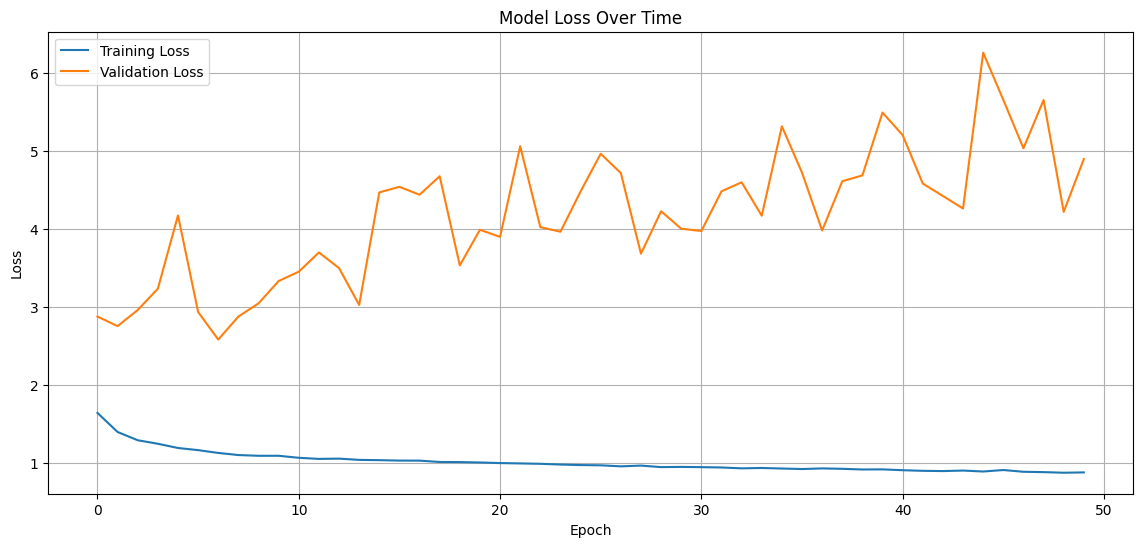

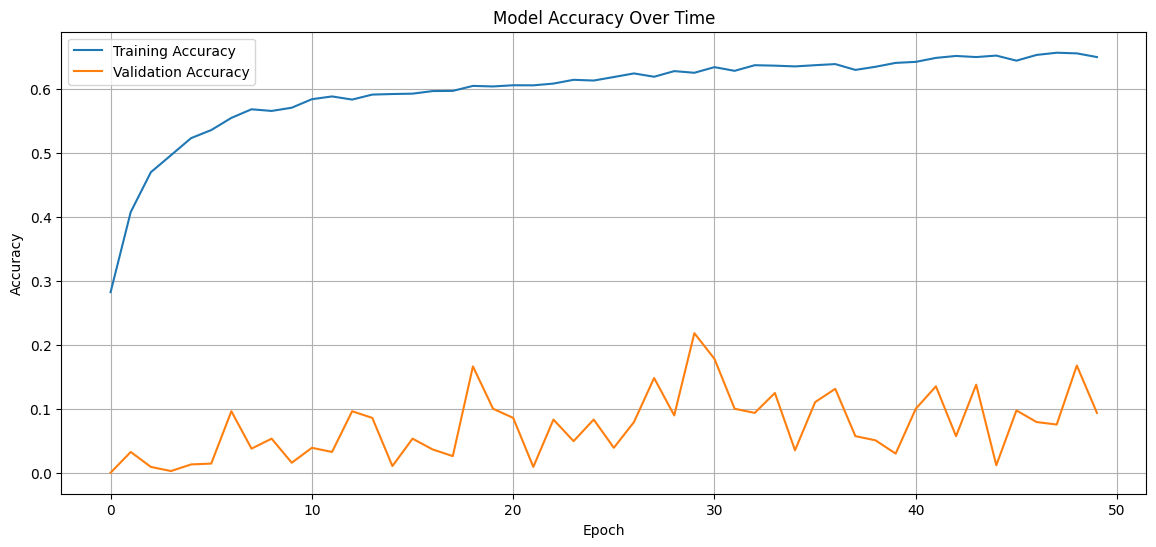


Evaluating RNN...
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

       angry       0.64      0.83      0.72       391
     disgust       0.64      0.23      0.34       373
        fear       0.79      0.54      0.64       398
       happy       0.59      0.73      0.65       379
     neutral       0.56      0.81      0.66       398
         sad       0.68      0.64      0.66       369

    accuracy                           0.63      2308
   macro avg       0.65      0.63      0.61      2308
weighted avg       0.65      0.63      0.61      2308



In [88]:
# Reshape for RNN (LSTM expects 3D input: samples, timesteps, features)
X_train_rnn = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_rnn = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Train RNN Model
rnn_model = Sequential([
    LSTM(128, input_shape=(1, X_train.shape[1]), activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(64, activation='tanh'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the RNN model and store the history
print("Training RNN...")
history = rnn_model.fit(
    X_train_rnn, 
    y_train, 
    epochs=50, 
    batch_size=32, 
    verbose=1, 
    validation_split=0.1
)

# Save the trained model
rnn_model.save('emotion_model/emotion_rnn_model.h5')
print("Model saved as 'emotion_rnn_model.h5'")

# Plot training history
plt.figure(figsize=(14, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot accuracy history
plt.figure(figsize=(14, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Time')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate RNN Model
print("\nEvaluating RNN...")
y_pred_rnn = np.argmax(rnn_model.predict(X_test_rnn), axis=1)
print(classification_report(y_test, y_pred_rnn, target_names=le.classes_))

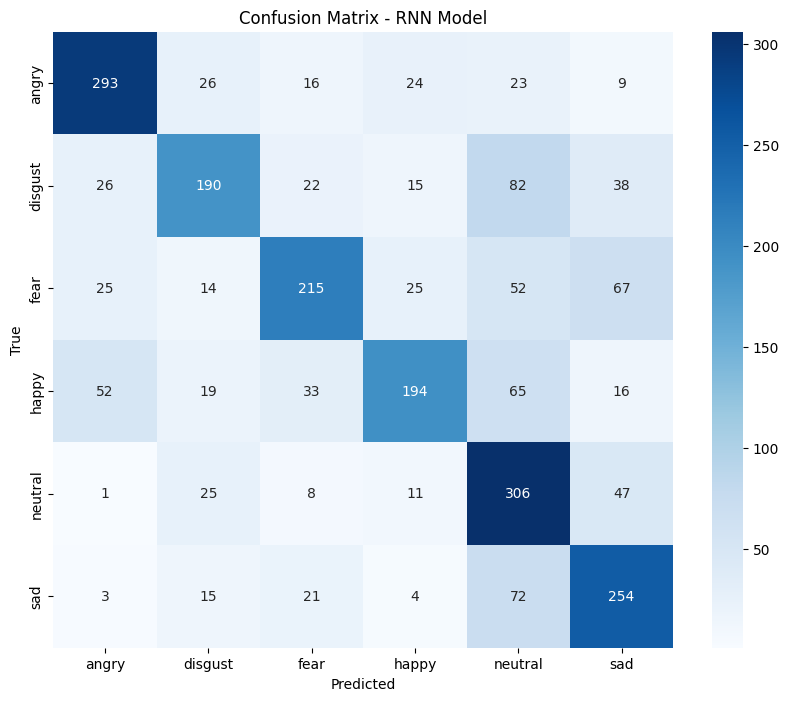


Detailed RNN Model Metrics:
Accuracy: 0.6291
Precision (weighted): 0.6469
Recall (weighted): 0.6291
F1 Score (weighted): 0.6273
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


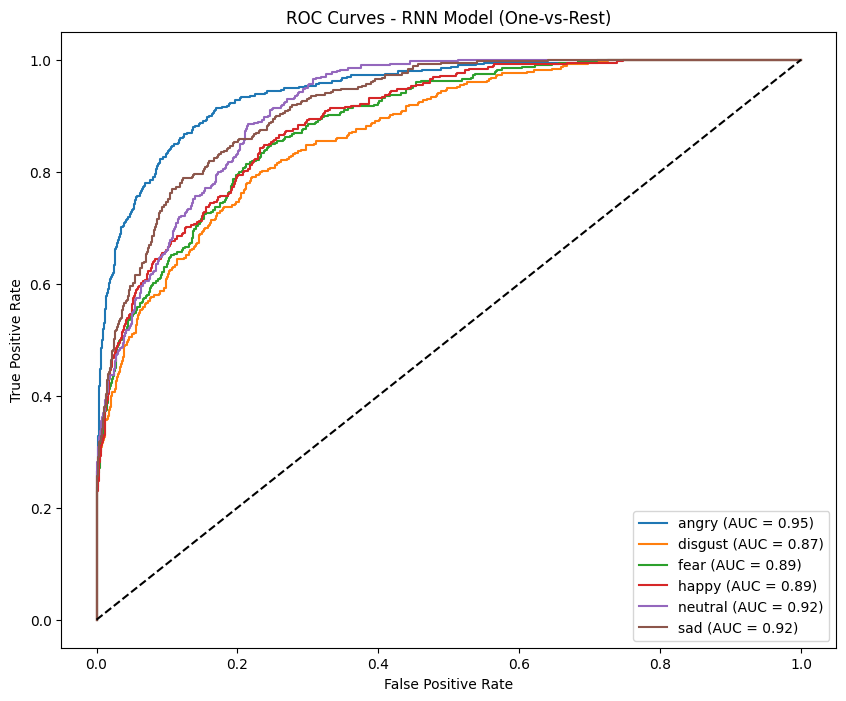

In [60]:
# Plot confusion matrix for RNN
plt.figure(figsize=(10, 8))
cm = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_pred_rnn))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - RNN Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Calculate and print additional metrics
print("\nDetailed RNN Model Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rnn):.4f}")
print(f"Precision (weighted): {precision_score(y_test, y_pred_rnn, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test, y_pred_rnn, average='weighted'):.4f}")
print(f"F1 Score (weighted): {f1_score(y_test, y_pred_rnn, average='weighted'):.4f}")

# Plot ROC curves for each class (one-vs-rest)
plt.figure(figsize=(10, 8))
y_pred_proba = rnn_model.predict(X_test_rnn)

for i in range(len(le.classes_)):
    y_test_binary = (y_test == i).astype(int)
    y_pred_proba_class = y_pred_proba[:, i]
    fpr, tpr, _ = roc_curve(y_test_binary, y_pred_proba_class)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{le.classes_[i]} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - RNN Model (One-vs-Rest)')
plt.legend()
plt.show()


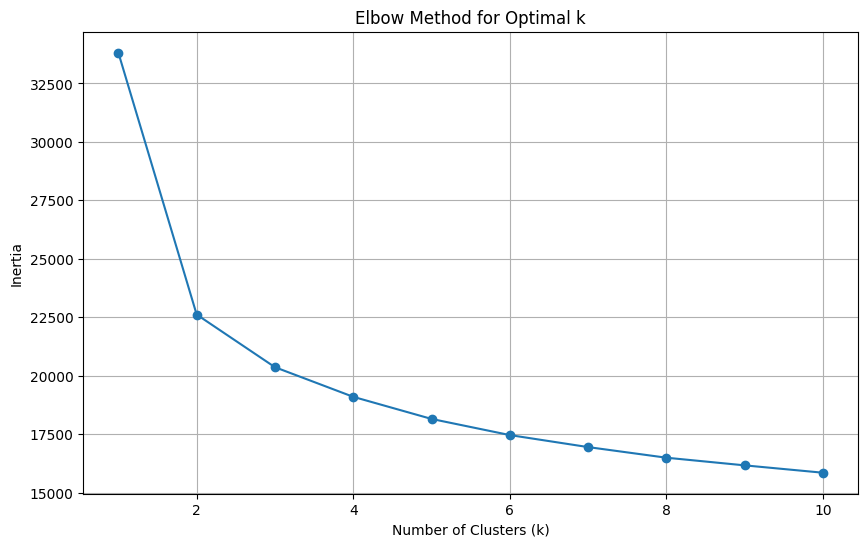

In [67]:
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

# Define the range of k values to try
k_values = range(1, 11)

# List to store the inertia values for each k
inertia_values = []

# Compute k-means clustering for each k and store the inertia
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)  # Use the scaled features
    inertia_values.append(kmeans.inertia_)

# Plot the inertia values against the number of clusters
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia_values, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [82]:
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Initialize KFold
k = 3 
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Initialize lists to store metrics
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Perform k-fold cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_scaled), 1):
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y_encoded[train_index], y_encoded[val_index]

    # Reshape for RNN (LSTM expects 3D input: samples, timesteps, features)
    X_train_rnn = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
    X_val_rnn = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])

    # RNN model
    rnn_model = Sequential([
        LSTM(128, input_shape=(1, X_train.shape[1]), activation='tanh', return_sequences=True),
        Dropout(0.2),
        LSTM(64, activation='tanh'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(len(np.unique(y_encoded)), activation='softmax')
    ])
    rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train the model
    history = rnn_model.fit(X_train_rnn, y_train, epochs=50, batch_size=32, verbose=1, validation_data=(X_val_rnn, y_val))

    # Evaluate the model
    y_pred_val = np.argmax(rnn_model.predict(X_val_rnn), axis=1)
    accuracy_scores.append(accuracy_score(y_val, y_pred_val))
    precision_scores.append(precision_score(y_val, y_pred_val, average='weighted'))
    recall_scores.append(recall_score(y_val, y_pred_val, average='weighted'))
    f1_scores.append(f1_score(y_val, y_pred_val, average='weighted'))

    print(f"\nFold {fold} Classification Report:")
    print(classification_report(y_val, y_pred_val, target_names=le.classes_))

# Print the average metrics
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1 Score: {np.mean(f1_scores):.4f}")

Epoch 1/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2108 - loss: 1.7549 - val_accuracy: 0.3539 - val_loss: 1.4942
Epoch 2/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3634 - loss: 1.5019 - val_accuracy: 0.4688 - val_loss: 1.3434
Epoch 3/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4065 - loss: 1.3964 - val_accuracy: 0.5107 - val_loss: 1.2706
Epoch 4/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4553 - loss: 1.3166 - val_accuracy: 0.5187 - val_loss: 1.2143
Epoch 5/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4985 - loss: 1.2558 - val_accuracy: 0.5471 - val_loss: 1.1456
Epoch 6/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5106 - loss: 1.2114 - val_accuracy: 0.5621 - val_loss: 1.1150
Epoch 7/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5269 - loss: 1.1760 - val_accuracy: 0.5458 - val_loss: 1.1375
Epoch 8/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5206 - loss: 1.1798 - val_accuracy: 0.

### XGBoost


Training XGBoost model...


  warnings.warn(



[0]	validation_0-mlogloss:1.78253	validation_1-mlogloss:1.78364
[1]	validation_0-mlogloss:1.77348	validation_1-mlogloss:1.77571
[2]	validation_0-mlogloss:1.76462	validation_1-mlogloss:1.76786
[3]	validation_0-mlogloss:1.75591	validation_1-mlogloss:1.76023
[4]	validation_0-mlogloss:1.74724	validation_1-mlogloss:1.75259
[5]	validation_0-mlogloss:1.73871	validation_1-mlogloss:1.74506
[6]	validation_0-mlogloss:1.73043	validation_1-mlogloss:1.73779
[7]	validation_0-mlogloss:1.72218	validation_1-mlogloss:1.73053
[8]	validation_0-mlogloss:1.71408	validation_1-mlogloss:1.72338
[9]	validation_0-mlogloss:1.70611	validation_1-mlogloss:1.71630
[10]	validation_0-mlogloss:1.69826	validation_1-mlogloss:1.70946
[11]	validation_0-mlogloss:1.69052	validation_1-mlogloss:1.70261
[12]	validation_0-mlogloss:1.68292	validation_1-mlogloss:1.69592
[13]	validation_0-mlogloss:1.67544	validation_1-mlogloss:1.68942
[14]	validation_0-mlogloss:1.66798	validation_1-mlogloss:1.68282
[15]	validation_0-mlogloss:1.66069	

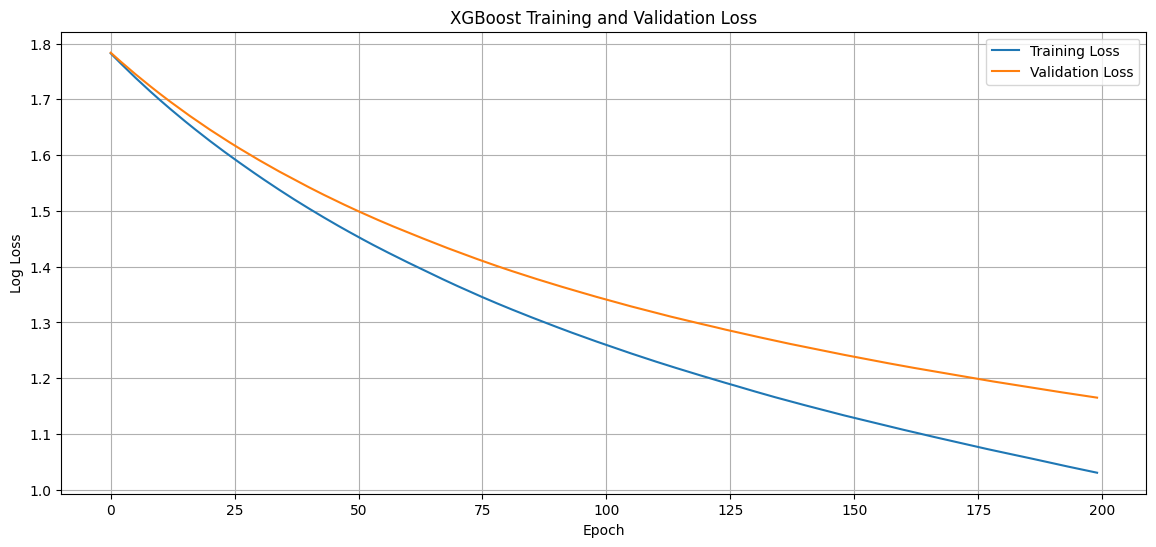


Evaluating XGBoost on Testing Data...
              precision    recall  f1-score   support

       angry       0.63      0.79      0.70       391
     disgust       0.64      0.43      0.52       373
        fear       0.68      0.46      0.55       398
       happy       0.57      0.54      0.56       379
     neutral       0.59      0.73      0.65       398
         sad       0.58      0.71      0.64       369

    accuracy                           0.61      2308
   macro avg       0.62      0.61      0.60      2308
weighted avg       0.62      0.61      0.60      2308


XGBoost Test Metrics:
Accuracy: 0.6105
Precision (weighted): 0.6168
Recall (weighted): 0.6105
F1 Score (weighted): 0.6029

Model saved as 'xgboost_model.joblib'


In [94]:
# Train XGBoost model
print("\nTraining XGBoost model...")
xgb_model = xgb.XGBClassifier(
    reg_lambda=5,  # L2 regularization
    reg_alpha=2,   # L1 regularization
    max_depth=6, 
    min_child_weight=5,
    n_estimators=200,
    learning_rate=0.01,
    eval_metric='mlogloss',
    random_state=42
)
xgb_model.fit(
    X_train, 
    y_train, 
    early_stopping_rounds=10, 
    eval_set=[(X_train, y_train), (X_test, y_test)],  
    verbose=True
)

# Plot training and validation loss
results = xgb_model.evals_result()
plt.figure(figsize=(14, 6))
plt.plot(results['validation_0']['mlogloss'], label='Training Loss')
plt.plot(results['validation_1']['mlogloss'], label='Validation Loss')
plt.title('XGBoost Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate on test set
print("\nEvaluating XGBoost on Testing Data...")
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb, average='weighted')
recall = recall_score(y_test, y_pred_xgb, average='weighted')
f1 = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"\nXGBoost Test Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}") 
print(f"F1 Score (weighted): {f1:.4f}")


# Save the model
import joblib
joblib.dump(xgb_model, 'emotion_model/emotion_xgboost_model.joblib')
print("\nModel saved as 'xgboost_model.joblib'")

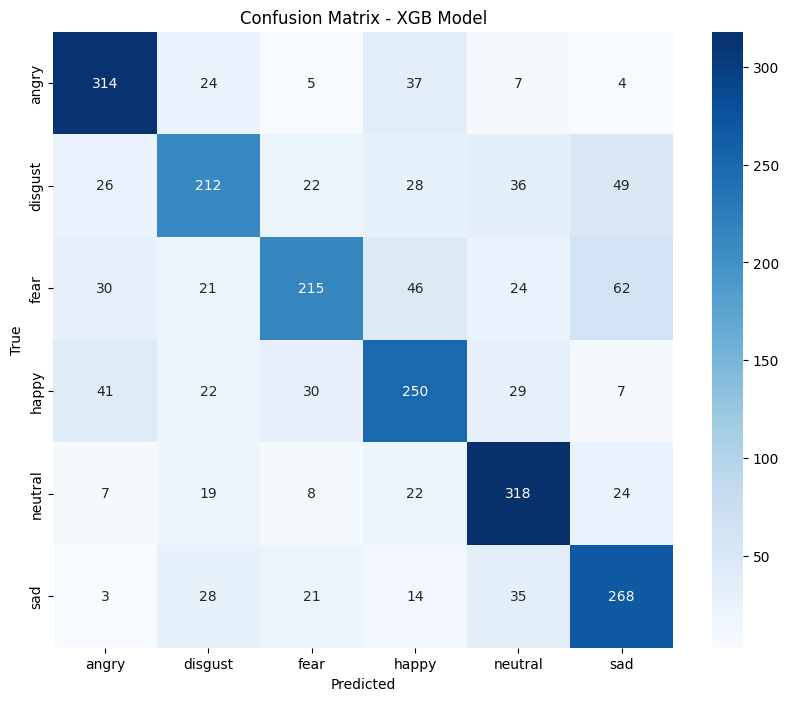

In [62]:
# Plot confusion matrix for XGB
plt.figure(figsize=(10, 8))
cm = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_pred_xgb))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - XGB Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [83]:
# Initialize KFold
k = 3 
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Initialize lists to store metrics
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Perform k-fold cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_scaled), 1):
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y_encoded[train_index], y_encoded[val_index]

    # XGBoost model
    xgb_model = xgb.XGBClassifier(
        reg_lambda=5,  # L2 regularization
        reg_alpha=2,   # L1 regularization
        max_depth=6, 
        min_child_weight=5,
        n_estimators=200,
        learning_rate=0.01,
        eval_metric='mlogloss',
        random_state=42
    )
    xgb_model.fit(X_train, y_train, early_stopping_rounds=10, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=True)

    # Evaluate the model
    y_pred_val = xgb_model.predict(X_val)
    accuracy_scores.append(accuracy_score(y_val, y_pred_val))
    precision_scores.append(precision_score(y_val, y_pred_val, average='weighted'))
    recall_scores.append(recall_score(y_val, y_pred_val, average='weighted'))
    f1_scores.append(f1_score(y_val, y_pred_val, average='weighted'))

    print(f"\nFold {fold} Classification Report:")
    print(classification_report(y_val, y_pred_val, target_names=le.classes_))

# Print the average metrics
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1 Score: {np.mean(f1_scores):.4f}")

[0]	validation_0-mlogloss:1.78250	validation_1-mlogloss:1.78349
[1]	validation_0-mlogloss:1.77341	validation_1-mlogloss:1.77538
[2]	validation_0-mlogloss:1.76443	validation_1-mlogloss:1.76741
[3]	validation_0-mlogloss:1.75566	validation_1-mlogloss:1.75963
[4]	validation_0-mlogloss:1.74700	validation_1-mlogloss:1.75197
[5]	validation_0-mlogloss:1.73848	validation_1-mlogloss:1.74449
[6]	validation_0-mlogloss:1.73009	validation_1-mlogloss:1.73714
[7]	validation_0-mlogloss:1.72191	validation_1-mlogloss:1.73000
[8]	validation_0-mlogloss:1.71380	validation_1-mlogloss:1.72284
[9]	validation_0-mlogloss:1.70580	validation_1-mlogloss:1.71586
[10]	validation_0-mlogloss:1.69798	validation_1-mlogloss:1.70912
[11]	validation_0-mlogloss:1.69029	validation_1-mlogloss:1.70250
[12]	validation_0-mlogloss:1.68271	validation_1-mlogloss:1.69590
[13]	validation_0-mlogloss:1.67524	validation_1-mlogloss:1.68946
[14]	validation_0-mlogloss:1.66784	validation_1-mlogloss:1.68303
[15]	validation_0-mlogloss:1.66054	

### Random Forest


Training Random Forest model...


  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(



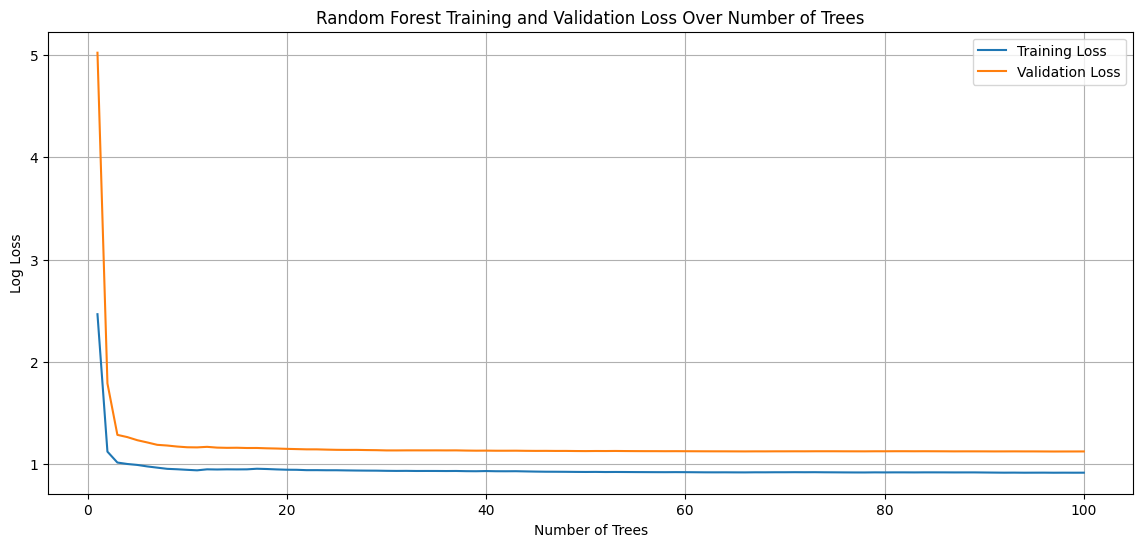


Evaluating Random Forest on Testing Data...
              precision    recall  f1-score   support

       angry       0.62      0.83      0.71       391
     disgust       0.60      0.45      0.52       373
        fear       0.77      0.41      0.54       398
       happy       0.60      0.58      0.59       379
     neutral       0.63      0.77      0.69       398
         sad       0.60      0.72      0.65       369

    accuracy                           0.63      2308
   macro avg       0.64      0.63      0.62      2308
weighted avg       0.64      0.63      0.62      2308


Random Forest Test Metrics:
Accuracy: 0.6261
Precision (weighted): 0.6373
Recall (weighted): 0.6261
F1 Score (weighted): 0.6162

Model saved as 'rf_model.joblib'


In [95]:
from sklearn.metrics import log_loss

# Train Random Forest Model
print("\nTraining Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=100,        # Fewer trees
    max_depth=10,            # Restrict depth
    min_samples_split=10,    # Require more samples to split
    min_samples_leaf=5,      # Require more samples in leaf nodes
    max_features='sqrt',     # Consider sqrt(number of features) at each split
    oob_score=True,          # Enable out-of-bag estimates
    random_state=42,
)
# Arrays to store the training and validation loss
train_losses = []
val_losses = []

# Train the model incrementally
n_estimators = 100  # Number of trees
for i in range(1, n_estimators + 1):
    rf_model.set_params(n_estimators=i)
    rf_model.fit(X_train, y_train)
    
    # Predict probabilities for training and validation sets
    y_train_pred_proba = rf_model.predict_proba(X_train)
    y_val_pred_proba = rf_model.predict_proba(X_test)
    
    # Calculate log loss for training and validation sets
    train_loss = log_loss(y_train, y_train_pred_proba)
    val_loss = log_loss(y_test, y_val_pred_proba)
    
    # Store the losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)

# Plot training and validation loss
plt.figure(figsize=(14, 6))
plt.plot(range(1, n_estimators + 1), train_losses, label='Training Loss')
plt.plot(range(1, n_estimators + 1), val_losses, label='Validation Loss')
plt.title('Random Forest Training and Validation Loss Over Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()


# Evaluate on test set
print("\nEvaluating Random Forest on Testing Data...")
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
f1 = f1_score(y_test, y_pred_rf, average='weighted')

print(f"\nRandom Forest Test Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}") 
print(f"F1 Score (weighted): {f1:.4f}")

# Save the model
joblib.dump(rf_model, 'emotion_model/emotion_rf_model.joblib')
print("\nModel saved as 'rf_model.joblib'")

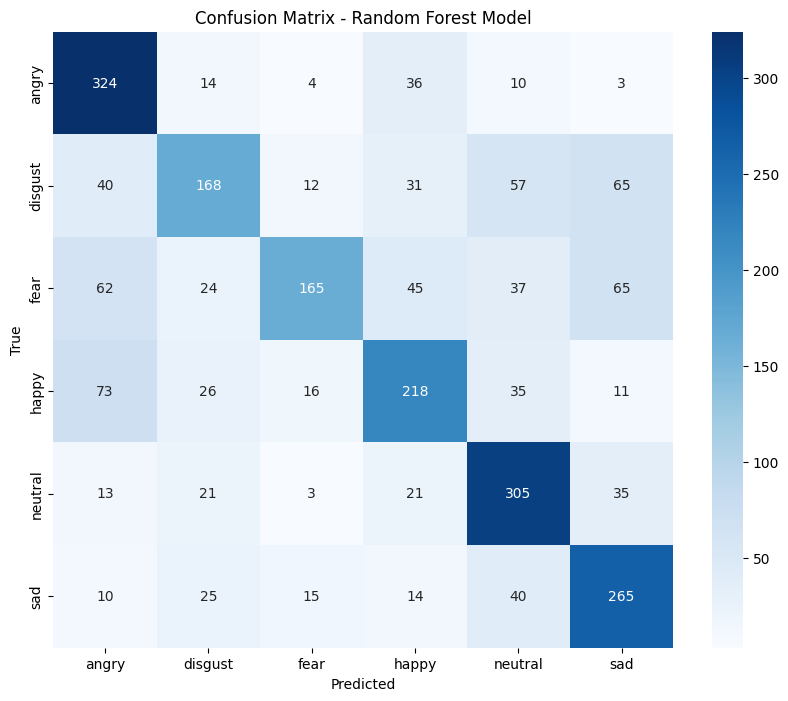

In [64]:
# Plot confusion matrix for Random Forest
plt.figure(figsize=(10, 8))
cm = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_pred_rf))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [78]:
# Initialize KFold
k = 2 
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Initialize lists to store metrics
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Perform k-fold cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_scaled), 1):
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y_encoded[train_index], y_encoded[val_index]

    # Random Forest model
    rf_model = RandomForestClassifier(
        n_estimators=100,        # Number of trees
        max_depth=10,            # Maximum depth of the tree
        min_samples_split=10,    # Minimum number of samples required to split an internal node
        min_samples_leaf=5,      # Minimum number of samples required to be at a leaf node
        max_features='sqrt',     # Number of features to consider when looking for the best split
        oob_score=True,          # Use out-of-bag samples to estimate the generalization accuracy
        random_state=42,
    )
    rf_model.fit(X_train, y_train)

    # Evaluate the model
    y_pred_val = rf_model.predict(X_val)
    accuracy_scores.append(accuracy_score(y_val, y_pred_val))
    precision_scores.append(precision_score(y_val, y_pred_val, average='weighted'))
    recall_scores.append(recall_score(y_val, y_pred_val, average='weighted'))
    f1_scores.append(f1_score(y_val, y_pred_val, average='weighted'))

    print(f"\nFold {fold} Classification Report:")
    print(classification_report(y_val, y_pred_val, target_names=le.classes_))

# Print the average metrics
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1 Score: {np.mean(f1_scores):.4f}")



Fold 1 Classification Report:
              precision    recall  f1-score   support

       angry       0.57      0.80      0.67       929
     disgust       0.59      0.46      0.51       955
        fear       0.72      0.41      0.52       951
       happy       0.56      0.53      0.54       959
     neutral       0.61      0.75      0.67       994
         sad       0.62      0.66      0.64       981

    accuracy                           0.60      5769
   macro avg       0.61      0.60      0.59      5769
weighted avg       0.61      0.60      0.59      5769


Fold 2 Classification Report:
              precision    recall  f1-score   support

       angry       0.60      0.78      0.68       994
     disgust       0.57      0.48      0.52       968
        fear       0.68      0.38      0.49       972
       happy       0.58      0.50      0.54       964
     neutral       0.61      0.74      0.67       929
         sad       0.56      0.70      0.62       942

    accuracy   

### SVM


Training SVM model...


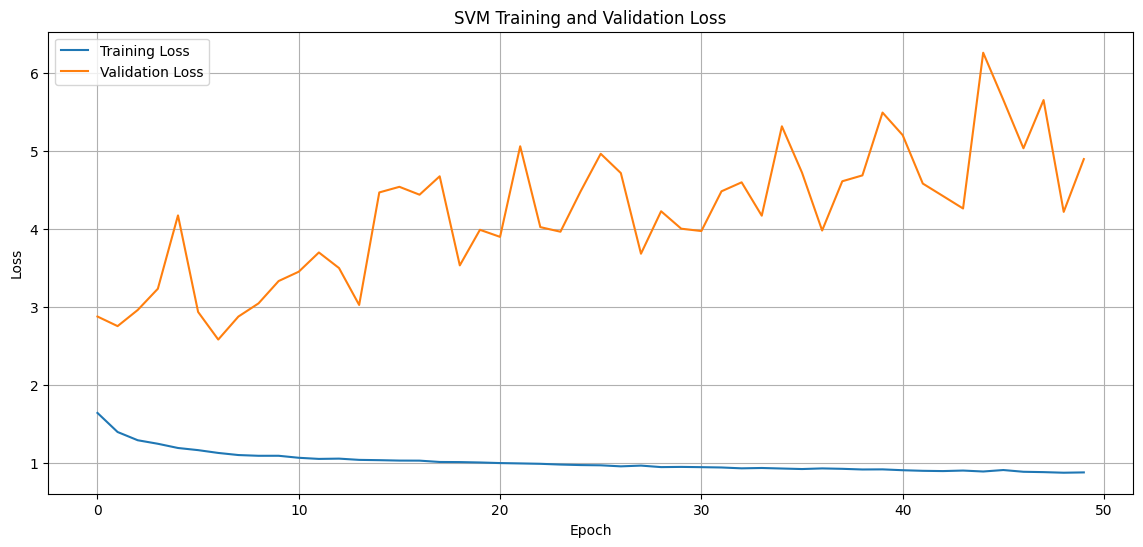


Evaluating SVM...
              precision    recall  f1-score   support

       angry       0.75      0.79      0.77       391
     disgust       0.62      0.58      0.60       373
        fear       0.64      0.59      0.61       398
       happy       0.68      0.66      0.67       379
     neutral       0.72      0.71      0.71       398
         sad       0.65      0.72      0.68       369

    accuracy                           0.68      2308
   macro avg       0.67      0.68      0.68      2308
weighted avg       0.68      0.68      0.68      2308


SVM Test Metrics:
Accuracy: 0.6768
Precision (weighted): 0.6756
Recall (weighted): 0.6768
F1 Score (weighted): 0.6755

Model saved as 'svm_model.joblib'


In [96]:
# Train SVM model
print("\nTraining SVM model...")
svm_model = SVC(
    C=10,           # Increase regularization
    kernel='rbf',   # Use RBF kernel for non-linear relationships
    gamma='scale',  # Start with 'scale' or fine-tune
    random_state=42,
    probability=True
)
svm_model.fit(X_train, y_train)

# Plot training and validation loss
plt.figure(figsize=(14, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('SVM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Evaluate on test set
print("\nEvaluating SVM...")
y_pred_svm = svm_model.predict(X_test)
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))
accuracy = accuracy_score(y_test, y_pred_svm)
precision = precision_score(y_test, y_pred_svm, average='weighted')
recall = recall_score(y_test, y_pred_svm, average='weighted')
f1 = f1_score(y_test, y_pred_svm, average='weighted')

print(f"\nSVM Test Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}") 
print(f"F1 Score (weighted): {f1:.4f}")


# Save the model
joblib.dump(svm_model, 'emotion_model/emotion_svm_model.joblib')
print("\nModel saved as 'svm_model.joblib'")


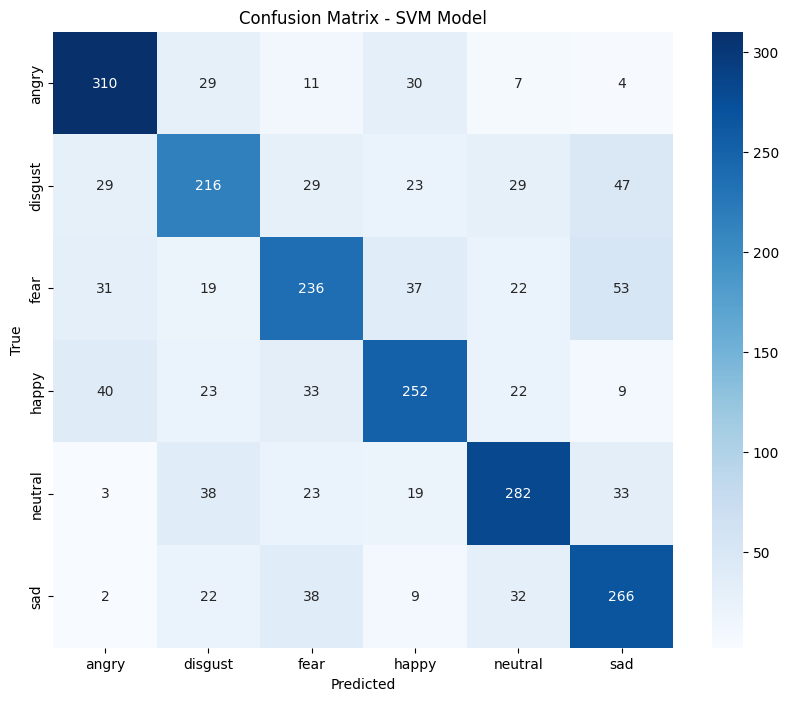

In [66]:
# Plot confusion matrix for SVM
plt.figure(figsize=(10, 8))
cm = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_pred_svm))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - SVM Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [79]:
# Initialize KFold
k = 2 
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Initialize lists to store metrics
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Perform k-fold cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_scaled), 1):
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y_encoded[train_index], y_encoded[val_index]

    svm_model = SVC(
        C=10,           # Increase regularization
        kernel='rbf',   # Use RBF kernel for non-linear relationships
        gamma='scale',  # Start with 'scale' or fine-tune
        random_state=42
    )
    svm_model.fit(X_train, y_train)

    # Evaluate the model
    y_pred_val = svm_model.predict(X_val)
    accuracy_scores.append(accuracy_score(y_val, y_pred_val))
    precision_scores.append(precision_score(y_val, y_pred_val, average='weighted'))
    recall_scores.append(recall_score(y_val, y_pred_val, average='weighted'))
    f1_scores.append(f1_score(y_val, y_pred_val, average='weighted'))

    print(f"\nFold {fold} Classification Report:")
    print(classification_report(y_val, y_pred_val, target_names=le.classes_))

# Print the average metrics
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1 Score: {np.mean(f1_scores):.4f}")


Fold 1 Classification Report:
              precision    recall  f1-score   support

       angry       0.71      0.77      0.74       929
     disgust       0.59      0.57      0.58       955
        fear       0.63      0.59      0.61       951
       happy       0.64      0.61      0.62       959
     neutral       0.66      0.70      0.68       994
         sad       0.65      0.66      0.66       981

    accuracy                           0.65      5769
   macro avg       0.65      0.65      0.65      5769
weighted avg       0.65      0.65      0.65      5769


Fold 2 Classification Report:
              precision    recall  f1-score   support

       angry       0.69      0.76      0.72       994
     disgust       0.57      0.58      0.58       968
        fear       0.64      0.56      0.60       972
       happy       0.63      0.56      0.60       964
     neutral       0.66      0.66      0.66       929
         sad       0.62      0.68      0.65       942

    accuracy   

### Ensemble

In [10]:
# Load the trained models
rnn_model = tf.keras.models.load_model('emotion_model/emotion_rnn_model.h5')
xgb_model = joblib.load('emotion_model/emotion_xgboost_model.joblib')
rf_model = joblib.load('emotion_model/emotion_rf_model.joblib')
svm_model = joblib.load('emotion_model/emotion_svm_model.joblib')

73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[4 0 5 ... 2 5 0]
[5 0 3 ... 2 5 0]
Ensemble Model Classification Report:
              precision    recall  f1-score   support

       angry       0.73      0.85      0.78       391
     disgust       0.72      0.51      0.60       373
        fear       0.74      0.55      0.63       398
       happy       0.65      0.69      0.67       379
     neutral       0.65      0.78      0.71       398
         sad       0.66      0.74      0.70       369

    accuracy                           0.69      2308
   macro avg       0.69      0.69      0.68      2308
weighted avg       0.69      0.69      0.68      2308



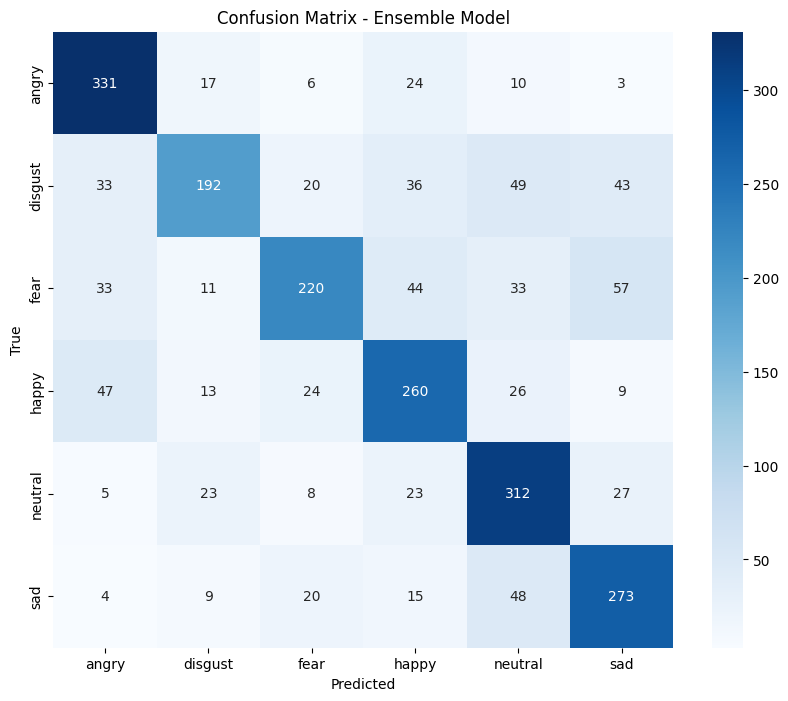


Detailed Ensemble Model Metrics:
Accuracy: 0.6880
Precision (weighted): 0.6929
Recall (weighted): 0.6880
F1 Score (weighted): 0.6831


In [13]:
X_test_rnn = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])
# Predict probabilities for each model
rnn_pred_proba = rnn_model.predict(X_test_rnn)
xgb_pred_proba = xgb_model.predict_proba(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)
svm_pred_proba = svm_model.predict_proba(X_test)

# Average the probabilities (soft voting)
ensemble_pred_proba = (rnn_pred_proba + xgb_pred_proba + rf_pred_proba + svm_pred_proba) / 4

# Get the final predictions by taking the class with the highest average probability
ensemble_pred = np.argmax(ensemble_pred_proba, axis=1)
print(ensemble_pred)
print(y_test)

# Evaluate the ensemble model
print("Ensemble Model Classification Report:")
print(classification_report(y_test, ensemble_pred, target_names=le.classes_))

# Plot confusion matrix for Ensemble Model
plt.figure(figsize=(10, 8))
cm = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(ensemble_pred))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Ensemble Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Calculate and print additional metrics
print("\nDetailed Ensemble Model Metrics:")
print(f"Accuracy: {accuracy_score(y_test, ensemble_pred):.4f}")
print(f"Precision (weighted): {precision_score(y_test, ensemble_pred, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test, ensemble_pred, average='weighted'):.4f}")
print(f"F1 Score (weighted): {f1_score(y_test, ensemble_pred, average='weighted'):.4f}")


In [15]:
from sklearn.metrics import accuracy_score

# Calculate accuracy for each model
accuracy_rnn = accuracy_score(y_test, np.argmax(rnn_pred_proba, axis=1))
accuracy_xgb = accuracy_score(y_test, np.argmax(xgb_pred_proba, axis=1))
accuracy_rf = accuracy_score(y_test, np.argmax(rf_pred_proba, axis=1))
accuracy_svm = accuracy_score(y_test, np.argmax(svm_pred_proba, axis=1))
accuracy_ensemble = accuracy_score(y_test, ensemble_pred)

# Print the accuracy of each model
print(f"RNN Model Accuracy: {accuracy_rnn:.4f}")
print(f"XGBoost Model Accuracy: {accuracy_xgb:.4f}")
print(f"Random Forest Model Accuracy: {accuracy_rf:.4f}")
print(f"SVM Model Accuracy: {accuracy_svm:.4f}")
print(f"Ensemble Model Accuracy: {accuracy_ensemble:.4f}")

RNN Model Accuracy: 0.6321
XGBoost Model Accuracy: 0.6105
Random Forest Model Accuracy: 0.6261
SVM Model Accuracy: 0.6802
Ensemble Model Accuracy: 0.6880
